In [1]:
import os
import cv2
import clip
import torch
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from PIL import Image, ImageDraw

In [2]:
category_name = ["battery", "framework", "hand", "signalinterfaceboard", "stringer", "warehouse"]
data_path = "/workspaces/assemblyhelper/dataset/labels"

In [3]:
category_list = os.listdir(data_path)
print(category_list)

['warehouse', 'stringer', 'hand', 'signalinterfaceboard', 'battery', 'framework']


In [4]:
# Load CLIP
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model, preprocess = clip.load("ViT-B/32", device=device)

In [5]:
def pad_to_square(input_image, fill_color=(0, 0, 0)):
    width, height = input_image.size
    new_size = max(width, height)
    new_image = Image.new("RGB", (new_size, new_size), fill_color)
    
    left = (new_size - width) // 2
    top = (new_size - height) // 2    
    
    new_image.paste(input_image, (left, top))
    return new_image

In [6]:
def normalize_feature(feature):
    if len(feature.shape) == 1:
        feature = feature.unsqueeze(0)
        
    min_values, _ = torch.min(feature, dim=1, keepdim=True)
    max_values, _ = torch.max(feature, dim=1, keepdim=True)
    
    feature = (feature - min_values) / (max_values - min_values)
    return feature

In [7]:
# def pad_to_square(input_image, fill_color=(0, 0, 0)):
#     width, height = input_image.size
#     new_size = max(width, height)
#     padding = min(width, height) // 10
    
#     new_size += 2 * padding
#     new_image = Image.new("RGB", (new_size, new_size), fill_color)
    
#     left = (new_size - width) // 2
#     top = (new_size - height) // 2
    
#     new_image.paste(input_image, (left, top))
# #     new_image.resize((512, 512))
#     return new_image

In [8]:
images = []
for cate in category_name:
    img_path = os.path.join(data_path, cate)
    img_list = os.listdir(img_path)
    image = []
    for im in img_list:
        image.append(pad_to_square(Image.open(os.path.join(img_path, im))))
    images.append(image)
    
print(images[2])

[<PIL.Image.Image image mode=RGB size=201x201 at 0x7FA90921E590>, <PIL.Image.Image image mode=RGB size=287x287 at 0x7FA90921E8D0>, <PIL.Image.Image image mode=RGB size=334x334 at 0x7FA90921EE10>, <PIL.Image.Image image mode=RGB size=268x268 at 0x7FA90921EE90>, <PIL.Image.Image image mode=RGB size=226x226 at 0x7FA90921EF10>, <PIL.Image.Image image mode=RGB size=223x223 at 0x7FA90921EF50>, <PIL.Image.Image image mode=RGB size=216x216 at 0x7FA90921E9D0>, <PIL.Image.Image image mode=RGB size=161x161 at 0x7FA90921E710>]


In [9]:
images_features = []

view_means = []
view_vars = []

for image in images:
    preprocessed_img = torch.stack([preprocess(im).to(device) for im in image])
    img_feature = model.encode_image(preprocessed_img)
    img_feature /= img_feature.norm(dim=-1, keepdim=True)
    images_features.append(img_feature.detach())
    
    # 每个类别的均值（view的均值）
    view_mean = torch.mean(img_feature, dim=0, keepdim=False)
    view_means.append(view_mean)
    # 每个类别的方差（view的方差）
    view_var = torch.var(img_feature, dim=0, keepdim=False)
    view_vars.append(view_var)

# images_features = torch.stack(images_features).detch().cpu()
view_means = torch.stack(view_means).detach().cpu()
view_vars = torch.stack(view_vars).detach().cpu()

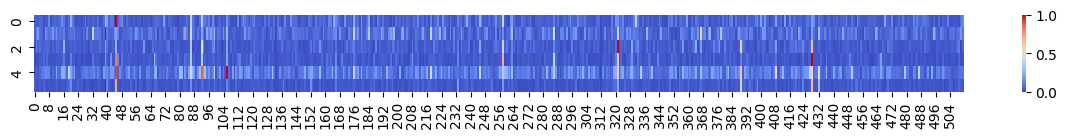

In [10]:
# 可视化每个物体的不同视角的方差
plt.figure(figsize=(15, 1))
view_vars_norm = normalize_feature(view_vars)
sns.heatmap(view_vars_norm, cmap="coolwarm")
plt.show()

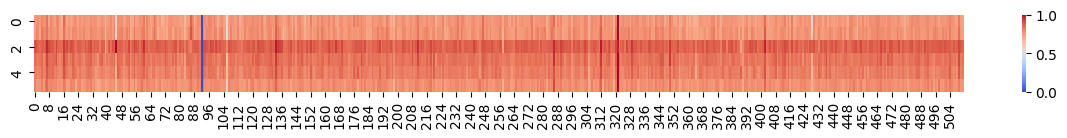

In [11]:
# 可视化不同物体的平均视角
plt.figure(figsize=(15, 1))
view_means_norm = normalize_feature(view_means)
sns.heatmap(view_means_norm, cmap="coolwarm")
plt.show()

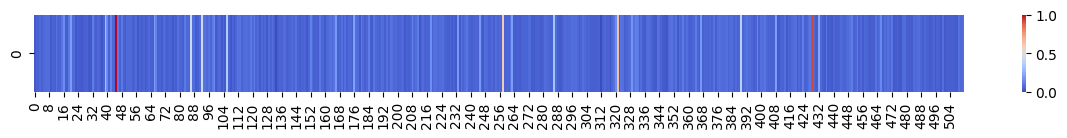

tensor(133)


In [12]:
# 可视化不同视角的方差的均值
plt.figure(figsize=(15, 1))
view_vars_mean = torch.mean(view_vars, dim=0, keepdim=False)
view_vars_mean_norm = normalize_feature(view_vars_mean)
sns.heatmap(view_vars_mean_norm[:,:], cmap="coolwarm")
plt.show()
print(torch.argmin(view_vars_mean_norm))

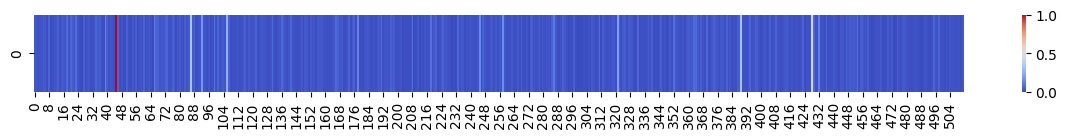

tensor(55)


In [13]:
# 可视化不同视角均值的方差
view_means_var = torch.var(view_means, dim=0)
view_means_var_norm = normalize_feature(view_means_var)
plt.figure(figsize=(15, 1))
sns.heatmap(view_means_var_norm[:, :], cmap="coolwarm")
plt.show()
print(torch.argmin(view_means_var_norm))

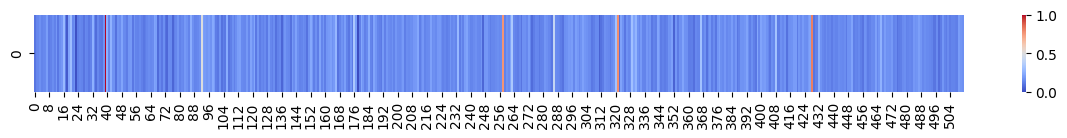

In [14]:
# 可视化不同clip的视角特征和物体特征的差异
plt.figure(figsize=(15, 1))
related_feature = view_vars_mean_norm - view_means_var_norm
related_feature_norm = normalize_feature(related_feature)
sns.heatmap(related_feature_norm, cmap="coolwarm")
plt.show()

In [82]:
# 筛选出物体变化的主要影响的特征向量，排除视角影响的特征向量
sorted_indices = torch.argsort(view_means_var_norm, descending=True).squeeze(0)
# sorted_indices = torch.argsort(related_feature_norm, descending=True).squeeze(0)
select_indices = sorted_indices[:]
sorted_indices = torch.argsort(view_vars_mean_norm, descending=True).squeeze(0)
remove_indices = sorted_indices[:256]

final_indices = []
for idx in select_indices:
    if len(final_indices) == 64 * 2:
        break
    if idx in remove_indices:
        continue
    final_indices.append(idx)

print(final_indices)
print(len(final_indices))
print(torch.argmax(view_means_var_norm))

[tensor(352), tensor(18), tensor(23), tensor(311), tensor(136), tensor(73), tensor(370), tensor(68), tensor(72), tensor(498), tensor(101), tensor(34), tensor(107), tensor(291), tensor(76), tensor(122), tensor(247), tensor(285), tensor(475), tensor(13), tensor(274), tensor(405), tensor(268), tensor(360), tensor(340), tensor(167), tensor(345), tensor(397), tensor(325), tensor(27), tensor(387), tensor(322), tensor(36), tensor(313), tensor(375), tensor(459), tensor(278), tensor(362), tensor(77), tensor(414), tensor(456), tensor(307), tensor(266), tensor(236), tensor(190), tensor(373), tensor(451), tensor(175), tensor(361), tensor(103), tensor(54), tensor(156), tensor(0), tensor(251), tensor(189), tensor(70), tensor(504), tensor(150), tensor(259), tensor(147), tensor(30), tensor(240), tensor(227), tensor(154), tensor(226), tensor(193), tensor(168), tensor(140), tensor(502), tensor(308), tensor(69), tensor(396), tensor(105), tensor(280), tensor(244), tensor(496), tensor(11), tensor(24), tens

In [21]:
# 一个物体的不同view和不同物体的平均特征之间的差异
print(f"==========view-feature==========")
obj_views_probs = []
for o_id in range(len(images_features)):
    view_means_single = view_means[o_id].unsqueeze(0)
#     print(f"=========={o_id}==========")
    max_view_probs = 0
    views_probs = []
    for v_id in range(images_features[o_id].shape[0]):
        image_feature = images_features[o_id][v_id].unsqueeze(0)
        probs = 1 - view_means_single.cuda() @ image_feature.detach().T
#         print(probs)        
        if probs > max_view_probs:
            max_view_probs = probs
        views_probs.append(probs)
        
    obj_views_probs.append(views_probs)
    print(max_view_probs)

print(f"==========obj-feature==========")
obj_probs = []
view_means_mean = torch.mean(view_means, dim=0, keepdim=True)
# print(view_means_mean.shape)
max_cate_prob = 0
min_cate_prob = 1
for o_id in range(len(images_features)):
    view_means_single = view_means[o_id].unsqueeze(0)
    probs = 1 - view_means_mean.cuda() @ view_means_single.cuda().T
#     print(probs)
    if probs > max_cate_prob:
        max_cate_prob = probs
    if probs < min_cate_prob:
        min_cate_prob = probs
    obj_probs.append(probs)
    
print(max_cate_prob)
print(min_cate_prob)

# 计算 view_diff 和 obj_diff
print("=========== DIFF between view & object ===========")
views_means = []
for views_probs in obj_views_probs:
    views_mean = torch.mean(torch.stack(views_probs))
    views_means.append(views_mean)
view_diff = torch.mean(torch.stack(views_means))

obj_diff = torch.mean(torch.stack(obj_probs))

print(view_diff)
print(obj_diff)
    

# print(category_name[0], category_name[3], category_name[4])
print(category_name)

==========view-feature==========
tensor([[0.0947]], device='cuda:0', dtype=torch.float16)
tensor([[0.0679]], device='cuda:0', dtype=torch.float16)
tensor([[0.0493]], device='cuda:0', dtype=torch.float16)
tensor([[0.1333]], device='cuda:0', dtype=torch.float16)
tensor([[0.0957]], device='cuda:0', dtype=torch.float16)
tensor([[0.0879]], device='cuda:0', dtype=torch.float16)
==========obj-feature==========
tensor([[0.2461]], device='cuda:0', dtype=torch.float16)
tensor([[0.1963]], device='cuda:0', dtype=torch.float16)
=========== DIFF between view & object ===========
tensor(0.0684, device='cuda:0', dtype=torch.float16)
tensor(0.2098, device='cuda:0', dtype=torch.float16)
['battery', 'framework', 'hand', 'signalinterfaceboard', 'stringer', 'warehouse']


In [27]:
# 一个物体的不同view和不同物体的平均特征之间的差异
print(f"==========view-feature==========")
obj_views_probs = []
for o_id in range(len(images_features)):
    view_means_single = view_means[o_id].unsqueeze(0)
    max_view_probs = 0
    views_probs = []
    for v_id in range(images_features[o_id].shape[0]):
        image_feature = images_features[o_id][v_id].unsqueeze(0)
        probs = 1 - view_means_single.cuda() @ image_feature.detach().T
        if probs > max_view_probs:
            max_view_probs = probs
        views_probs.append(probs)
    obj_views_probs.append(views_probs)
    print(max_view_probs)

print(f"==========obj-feature==========")
obj_probs = []
max_cate_prob = 0
min_cate_prob = 1
for i in range(len(images_features)):
    obj_1 = view_means[i].unsqueeze(0)
    for j in range(i+1, len(images_features)):
        obj_2 = view_means[j].unsqueeze(0)
        
        probs = 1 - obj_1.cuda() @ obj_2.cuda().T
        obj_probs.append(probs)


# 计算 view_diff 和 obj_diff
print("=========== DIFF between view & object ===========")
views_means = []
for views_probs in obj_views_probs:
    views_mean = torch.mean(torch.stack(views_probs))
    views_means.append(views_mean)
view_diff = torch.mean(torch.stack(views_means))

obj_diff = torch.mean(torch.stack(obj_probs))

print(view_diff)
print(obj_diff)
    

# print(category_name[0], category_name[3], category_name[4])
print(category_name)

==========view-feature==========
tensor([[0.0947]], device='cuda:0', dtype=torch.float16)
tensor([[0.0679]], device='cuda:0', dtype=torch.float16)
tensor([[0.0493]], device='cuda:0', dtype=torch.float16)
tensor([[0.1333]], device='cuda:0', dtype=torch.float16)
tensor([[0.0957]], device='cuda:0', dtype=torch.float16)
tensor([[0.0879]], device='cuda:0', dtype=torch.float16)
==========obj-feature==========
=========== DIFF between view & object ===========
tensor(0.0684, device='cuda:0', dtype=torch.float16)
tensor(0.2378, device='cuda:0', dtype=torch.float16)
['battery', 'framework', 'hand', 'signalinterfaceboard', 'stringer', 'warehouse']


In [83]:
# 一个物体的不同view和不同物体的平均特征之间的差异
print(f"==========view-feature==========")
obj_views_probs = []
for o_id in range(len(images_features)):
    view_means_single = view_means[o_id][final_indices].unsqueeze(0)
    view_means_single /= view_means_single.norm(dim=-1, keepdim=True)
    max_view_probs = 0
    views_probs = []
    for v_id in range(images_features[o_id].shape[0]):
        image_feature = images_features[o_id][v_id][final_indices].unsqueeze(0)
        image_feature /= image_feature.norm(dim=-1, keepdim=True)
        probs = 1 - view_means_single.cuda() @ image_feature.detach().T
        if probs > max_view_probs:
            max_view_probs = probs
        views_probs.append(probs)
    obj_views_probs.append(views_probs)
    print(max_view_probs)

    
# print(f"==========obj-feature==========")
obj_probs = []
max_cate_prob = 0
min_cate_prob = 1
for i in range(len(images_features)):
    obj_1 = view_means[i][final_indices].unsqueeze(0)
    obj_1 /= obj_1.norm(dim=-1, keepdim=True)
    for j in range(i+1, len(images_features)):
        obj_2 = view_means[j][final_indices].unsqueeze(0)
        obj_2 /= obj_2.norm(dim=-1, keepdim=True)
        probs = 1 - obj_1.cuda() @ obj_2.cuda().T
        obj_probs.append(probs)
    
# print(f"==========obj-feature==========")
# obj_probs = []
# view_means_mean = torch.mean(view_means, dim=0, keepdim=True)[:, final_indices]
# view_means_mean /= view_means_mean.norm(dim=-1, keepdim=True)
# print(view_means_mean.shape)
# max_cate_prob = 0
# min_cate_prob = 1
# for o_id in range(len(images_features)):
#     view_means_single = view_means[o_id][final_indices].unsqueeze(0)
#     view_means_single /= view_means_single.norm(dim=-1, keepdim=True) 
#     probs = 1 - view_means_mean.cuda() @ view_means_single.cuda().T
#     print(probs)
#     if probs > max_cate_prob:
#         max_cate_prob = probs
#     if probs < min_cate_prob:
#         min_cate_prob = probs
#     obj_probs.append(probs)
# print(max_cate_prob)
# print(min_cate_prob)

# 计算 view_diff 和 obj_diff
print("=========== DIFF between view & object ===========")
views_means = []
for views_probs in obj_views_probs:
    views_mean = torch.mean(torch.stack(views_probs))
    views_means.append(views_mean)
view_diff = torch.mean(torch.stack(views_means))

obj_diff = torch.mean(torch.stack(obj_probs))

print(view_diff)
print(obj_diff)

print(category_name)

==========view-feature==========
tensor([[0.1055]], device='cuda:0', dtype=torch.float16)
tensor([[0.0986]], device='cuda:0', dtype=torch.float16)
tensor([[0.0942]], device='cuda:0', dtype=torch.float16)
tensor([[0.1836]], device='cuda:0', dtype=torch.float16)
tensor([[0.1660]], device='cuda:0', dtype=torch.float16)
tensor([[0.1138]], device='cuda:0', dtype=torch.float16)
=========== DIFF between view & object ===========
tensor(0.0802, device='cuda:0', dtype=torch.float16)
tensor(0.6860, device='cuda:0', dtype=torch.float16)
['battery', 'framework', 'hand', 'signalinterfaceboard', 'stringer', 'warehouse']


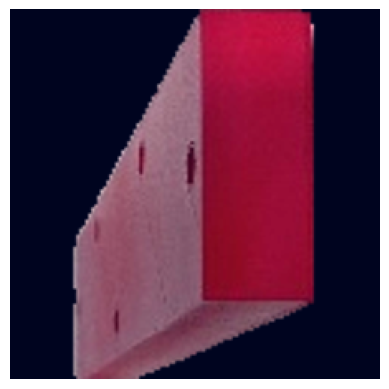

In [50]:
# 查看处理后的图像
pro_img = preprocess(images[4][5]).cpu().numpy()
# pro_img
pro_img = (pro_img - pro_img.min()) / (pro_img.max() - pro_img.min())
# 可视化图像
plt.imshow(pro_img.transpose((1, 2, 0)))
plt.axis('off')  # 隐藏坐标轴
plt.show()

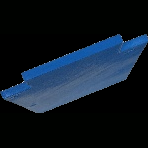

In [38]:
from PIL import Image

def pad_to_square(input_image, fill_color=(0, 0, 0)):
    width, height = input_image.size
    new_size = max(width, height)
    new_image = Image.new("RGB", (new_size, new_size), fill_color)
    
    left = (new_size - width) // 2
    top = (new_size - height) // 2
    
    new_image.paste(input_image, (left, top))
    return new_image

# 读取图像
input_image = Image.open("/workspaces/assemblyhelper/dataset/labels/signalinterfaceboard/2.png")

# 调整为正方形，填充颜色为白色
output_image = pad_to_square(input_image, 512)

# # 保存填充后的图像
# output_image.save("output.jpg")

# 显示填充后的图像
output_image.show()

In [50]:
# import numpy as np
# from sklearn.metrics.pairwise import cosine_similarity

# # 创建两组特征向量（示例数据）
# feature_vectors = np.random.rand(10, 100)  # 10个特征向量，每个向量包含100个特征

# # 计算余弦相似度矩阵
# cosine_sim_matrix = cosine_similarity(feature_vectors)

# # 找到最小和最大余弦相似度的索引
# min_similarity_index = np.unravel_index(np.argmin(cosine_sim_matrix, axis=None), cosine_sim_matrix.shape)
# max_similarity_index = np.unravel_index(np.argmax(cosine_sim_matrix, axis=None), cosine_sim_matrix.shape)

# # 打印最小和最大余弦相似度以及对应的特征向量
# print("最小余弦相似度：", cosine_sim_matrix[min_similarity_index])
# # print("对应的特征向量1：", feature_vectors[min_similarity_index[0]])
# # print("对应的特征向量2：", feature_vectors[min_similarity_index[1]])

In [37]:
print(cosine_sim_matrix.shape)

(10, 10)


In [22]:
a = torch.tensor([1,3,4]).unsqueeze(0)
b = a @ a.T
print(b)

tensor([[26]])
